# MobileFaceLoRA: Parameter-Efficient Face Recognition on Mobile Devices via Low-Rank Adaptation of Foundation Models

*Efficient face recognition on mobile devices via LoRA-adapted foundation models combined with lightweight architectures, evaluated on accuracy, inference speed, and memory footprint.*

**Key Idea:** Freeze a pre-trained CLIP-ViT backbone, inject tiny LoRA adapters (~1-2% extra params), and fine-tune with ArcFace loss on VGGFace2. Evaluate on LFW, AgeDB-30, CALFW, CPLFW benchmarks. Ablate LoRA rank to find the optimal accuracy-vs-size trade-off for mobile deployment.

---

### ═══ PHASE 1: ENVIRONMENT SETUP ═══

In [ ]:
# Install required packages
!pip install transformers peft torch torchvision scikit-learn matplotlib tqdm pillow timm tabulate

In [ ]:
!pip install facenet-pytorch

In [3]:
import os, sys, json, time, importlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Force this notebook to use the project copy of the core file.
# PROJECT_ROOT = r"E:\Richmond\Python\Final Project"
# os.chdir(PROJECT_ROOT)
# if PROJECT_ROOT not in sys.path:
#     sys.path.insert(0, PROJECT_ROOT)
# edgeface_path = os.path.join(PROJECT_ROOT, 'edgeface-master')
# if edgeface_path not in sys.path:
#     sys.path.insert(0, edgeface_path)

# Reload after kernel restart or core edits so presets are not stale.
import mobilefacelora_core
mobilefacelora_core = importlib.reload(mobilefacelora_core)

from mobilefacelora_core import (
    DEFAULT_CONFIG, make_experiment_config, set_reproducibility,
    get_device, build_training_data,
    VGGFace2Dataset, get_train_transforms, get_val_transforms,
    build_model, train, evaluate_all_benchmarks,
    ablation_study, export_for_mobile,
    plot_training_history, plot_ablation_results,
    print_results_table, evaluate_edgeface_baseline,
    BenchmarkPairDataset, extract_embeddings, evaluate_benchmark
)

device = get_device()
print("Core loaded from:", mobilefacelora_core.__file__)
print(f"\n{'='*60}")
print("  MobileFaceLoRA Hybrid Research Pipeline")
print(f"  Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0)}")
print(f"{'='*60}")


Core loaded from: /mnt/e/Richmond/Python/Final Project/mobilefacelora_core.py

  MobileFaceLoRA Hybrid Research Pipeline
  Device: cuda
  GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  Memory: _CudaDeviceProperties(name='NVIDIA GeForce RTX 4060 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=24, uuid=b4aa72c9-1db3-324a-c5a6-ba9743971d87, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=32MB)


### ═══ PHASE 2: DATASET ROLES (FR Protocol) ═══


| Dataset | Role | Details |
|---------|------|---------|
| **VGGFace2** (train) | Training embeddings | ~197K images, 540 identities |
| **LFW** | Benchmark | 6,000 pairs — standard unconstrained FR |
| **AgeDB-30** | Benchmark | 6,000 pairs — age variation robustness |
| **CALFW** | Benchmark | 6,000 pairs — cross-age LFW |
| **CPLFW** | Benchmark | 6,000 pairs — cross-pose robustness |


> **Rule:** Training identities do NOT appear in any benchmark dataset.

In [4]:
# Configuration: true MobileFaceLoRA-Hybrid run.
# This creates q,k,v,out LoRA + P x K identity batches + EdgeFace teacher distillation.
PRESET_NAME = "hybrid_teacher_qkvo_r8"
cfg = make_experiment_config(PRESET_NAME)

# Keep the run length explicit. Use None for full 7 epochs, or 3 for patience-based stopping.
cfg['epochs'] = 7
cfg['early_stopping_patience'] = None

# Optional follow-up knobs. Leave commented for the first hybrid run.
cfg['early_stopping_patience'] = 3
# cfg['distill_weight'] = 0.10
# cfg['distill_weight'] = 0.50
# cfg['sampler_identities_per_batch'] = 16
# cfg['sampler_images_per_identity'] = 4

set_reproducibility(cfg.get('seed', 42), cfg.get('deterministic', False))
os.makedirs(cfg['output_dir'], exist_ok=True)

expected_targets = ['q_proj', 'k_proj', 'v_proj', 'out_proj']
assert cfg['lora_targets'] == expected_targets, cfg['lora_targets']
assert cfg.get('use_pk_sampler') is True, cfg.get('use_pk_sampler')
assert cfg.get('use_teacher_distillation') is True, cfg.get('use_teacher_distillation')

print("Active preset:", PRESET_NAME)
print("early_stopping_patience:", cfg.get('early_stopping_patience'))
print("epochs:", cfg['epochs'])
print("lora_targets:", cfg['lora_targets'])
print("use_pk_sampler:", cfg.get('use_pk_sampler'))
print("use_teacher_distillation:", cfg.get('use_teacher_distillation'))
print("teacher_model_name:", cfg.get('teacher_model_name'))
print("distill_weight:", cfg.get('distill_weight'))
print("lora_lr:", cfg.get('lora_lr'))
print("head_lr:", cfg.get('head_lr'))
print(f"benchmarks: {list(cfg['benchmarks'].keys())}")


Active preset: hybrid_teacher_qkvo_r8
early_stopping_patience: 3
epochs: 7
lora_targets: ['q_proj', 'k_proj', 'v_proj', 'out_proj']
use_pk_sampler: True
use_teacher_distillation: True
teacher_model_name: edgeface_s_gamma_05
distill_weight: 0.25
lora_lr: 2e-05
head_lr: 0.0001
benchmarks: ['LFW', 'AgeDB_30', 'CALFW', 'CPLFW']


### ═══ PHASE 3: TRAINING DATA PREPARATION ═══

Load VGGFace2 dataset from identity sub-folders. Apply data augmentations:
- Alignment
- Random horizontal flip
- Random grayscale conversion
- Color jitter (brightness, contrast, saturation, hue)
- Random erasing
- Resize to 224×224 (CLIP-ViT input size)
- Normalize to [-1, 1]

In [ ]:
from tqdm.auto import tqdm
import glob
import importlib, sys, types, torch
from facenet_pytorch import MTCNN

mtcnn = MTCNN(
    image_size=224,
    margin=0,
    keep_all=False,
    post_process=False,
    device=device
)

raw_train_dir = os.path.join(os.getcwd(), 'data', 'raw_train')
aligned_train_dir = os.path.join(os.getcwd(), 'data', 'aligned_train_224')

def align_raw_dataset(raw_dir, aligned_dir):
    """
    Loops through the raw VGGFace2 Identity folders, detects the face,
    aligns, resizes to 112x112, and saves it into the aligned_train directory.
    Skips entirely if alignment was already completed.
    """
    # ── Fast check: if aligned dir already has identity subfolders, skip ──
    if os.path.isdir(aligned_dir):
        existing = [d for d in os.listdir(aligned_dir)
                    if os.path.isdir(os.path.join(aligned_dir, d))]
        if len(existing) > 0:
            total_imgs = sum(
                len(os.listdir(os.path.join(aligned_dir, d)))
                for d in existing
            )
            print(f"Alignment already complete: {len(existing)} identities, "
                f"{total_imgs:,} aligned images in {aligned_dir}")
            return

    # ── If no alignment is in the alignment directory. ─────────────────────
   

    def _ensure_torch_serialization_compat():
        mod = sys.modules.get('torch.utils.serialization')
        if mod is None:
            try:
                mod = importlib.import_module('torch.utils.serialization')
            except ModuleNotFoundError:
                mod = None

        has_load_config = False
        if mod is not None and hasattr(mod, 'config'):
            has_load_config = hasattr(mod.config, 'load')

        if mod is None or not has_load_config:
            if mod is None or getattr(mod, '__file__', None) is None:
                mod = types.ModuleType('torch.utils.serialization')
                sys.modules['torch.utils.serialization'] = mod
                setattr(torch.utils, 'serialization', mod)

            class _CompatLoadConfig:
                mmap = False
                calculate_storage_offsets = False
                endianness = None

            class _CompatSaveConfig:
                storage_alignment = 64
                use_pinned_memory_for_d2h = False

            class _CompatConfig:
                load = _CompatLoadConfig()
                save = _CompatSaveConfig()

            mod.config = _CompatConfig()
            if not hasattr(mod, 'magic_number'):
                mod.magic_number = 1

    _ensure_torch_serialization_compat()

    if not os.path.exists(aligned_dir):
        os.makedirs(aligned_dir)

    identities = [d for d in os.listdir(raw_dir) if os.path.isdir(os.path.join(raw_dir, d))]
    print(f"Found {len(identities)} identities in raw data folder to align...")

    for identity in tqdm(identities, desc="Aligning Identities"):
        raw_id_dir = os.path.join(raw_dir, identity)
        aligned_id_dir = os.path.join(aligned_dir, identity)
        os.makedirs(aligned_id_dir, exist_ok=True)

        img_paths = glob.glob(os.path.join(raw_id_dir, '*.[jp][pn]g')) + \
                    glob.glob(os.path.join(raw_id_dir, '*.jpeg'))

        for img_path in img_paths:
            img_name = os.path.basename(img_path)
            aligned_img_path = os.path.join(aligned_id_dir, img_name)

            if os.path.exists(aligned_img_path):
                continue

            try:
                img = Image.open(img_path).convert('RGB')
                mtcnn(img, save_path=aligned_img_path)
            except Exception as e:
                print(f"Could not process face in {img_name} - Skipping.")
                pass


align_raw_dataset(raw_train_dir, aligned_train_dir)
print("All face alignments saved into their respective Identity folders!")

[VGGFace2] 197368 images, 540 identities
[Sampler] P x K identity batches enabled: P=16, K=4, batch_size=64

Training: 197368 images, 540 identities
Batches per epoch: 3083
Dataset returns teacher images: True
Batch format: student images, teacher images, labels


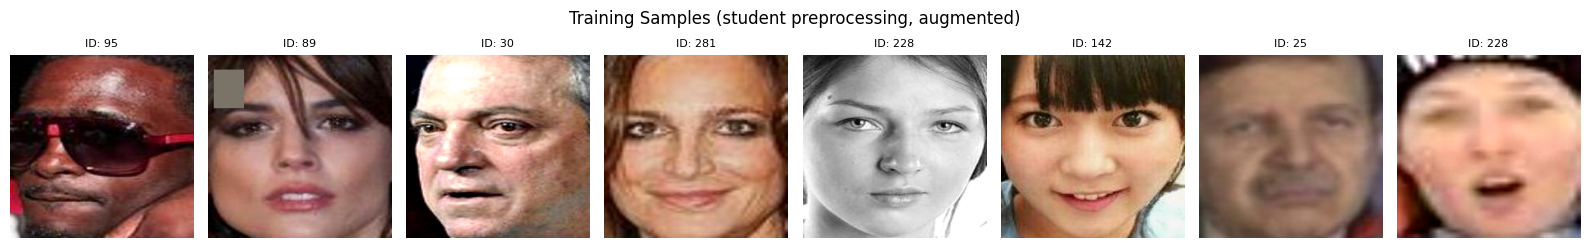

In [5]:
# Build training dataset and dataloader.
# Important: use build_training_data(cfg). Do not manually create VGGFace2Dataset/DataLoader for the hybrid run.
train_dataset, train_loader = build_training_data(cfg)

print(f"\nTraining: {len(train_dataset)} images, {train_dataset.num_classes} identities")
print(f"Batches per epoch: {len(train_loader)}")
print("Dataset returns teacher images:", getattr(train_dataset, 'teacher_transform', None) is not None)

# Visualize a few student-side training samples.
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
sample_batch = next(iter(train_loader))
if len(sample_batch) == 3:
    sample_imgs, sample_teacher_imgs, sample_labels = sample_batch
    print("Batch format: student images, teacher images, labels")
else:
    sample_imgs, sample_labels = sample_batch
    sample_teacher_imgs = None
    print("Batch format: student images, labels")

assert sample_teacher_imgs is not None, "Hybrid run expected teacher images, but the loader did not return them."

mean = torch.tensor(cfg['preprocess_mean']).view(3, 1, 1)
std = torch.tensor(cfg['preprocess_std']).view(3, 1, 1)
for i, ax in enumerate(axes):
    img = (sample_imgs[i].cpu() * std + mean).permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"ID: {sample_labels[i].item()}", fontsize=8)
    ax.axis('off')
plt.suptitle('Training Samples (student preprocessing, augmented)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(cfg['output_dir'], 'training_samples.png'), dpi=100)
plt.show()


### PHASE 4: MODEL ARCHITECTURE

**Hybrid architecture:** CLIP-ViT-Base/16 -> q/k/v/out LoRA adapters -> Projection (768 -> 512) -> BatchNorm -> ArcFace head.

This run also uses P x K identity-balanced batches and an EdgeFace teacher during training. The teacher is used only for distillation. At inference, MobileFaceLoRA still exports only its own embedding model.


In [6]:
# Build MobileFaceLoRA model
model = build_model(cfg, train_dataset.num_classes, device)

# Display architecture summary
print("\n--- Trainable Modules ---")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at

trainable params: 589,824 || all params: 86,389,248 || trainable%: 0.6828
[Model] Total: 87.06M | Trainable: 1.26M (1.45%)

--- Trainable Modules ---
  backbone.base_model.model.encoder.layers.0.self_attn.k_proj.lora_A.default.weight: torch.Size([8, 768])
  backbone.base_model.model.encoder.layers.0.self_attn.k_proj.lora_B.default.weight: torch.Size([768, 8])
  backbone.base_model.model.encoder.layers.0.self_attn.v_proj.lora_A.default.weight: torch.Size([8, 768])
  backbone.base_model.model.encoder.layers.0.self_attn.v_proj.lora_B.default.weight: torch.Size([768, 8])
  backbone.base_model.model.encoder.layers.0.self_attn.q_proj.lora_A.default.weight: torch.Size([8, 768])
  backbone.base_model.model.encoder.layers.0.self_attn.q_proj.lora_B.default.weight: torch.Size([768, 8])
  backbone.base_model.model.encoder.layers.0.self_attn.out_proj.lora_A.default.weight: torch.Size([8, 768])
  backbone.base_model.model.encoder.layers.0.self_attn.out_proj.lora_B.default.weight: torch.Size([768, 8]

### ═══ PHASE 5: LOSS FUNCTION — ArcFace ═══

**ArcFace** (Additive Angular Margin Loss) — gold standard for face recognition training.

$$\mathcal{L} = -\log \frac{e^{s \cdot \cos(\theta_{y_i} + m)}}{e^{s \cdot \cos(\theta_{y_i} + m)} + \sum_{j \neq y_i} e^{s \cdot \cos \theta_j}}$$

- Operates in **angular space** for cleaner geometric separation
- Scale $s = 64$, margin $m = 0.5$ (standard settings)
- The ArcFace head is integrated into our `MobileFaceLoRA` model class
- At inference: **discard** the head, use only the embedding

In [7]:
# Verify ArcFace loss on a student-side sample batch.
model.train()
sample_imgs_for_loss = sample_imgs[:8].to(device)
sample_labels_for_loss = sample_labels[:8].to(device)

with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
    logits, embeddings = model(sample_imgs_for_loss, sample_labels_for_loss)
    loss = F.cross_entropy(logits, sample_labels_for_loss)

print("ArcFace Loss Verification:")
print(f"  Input shape:     {sample_imgs_for_loss.shape}")
print(f"  Embedding shape: {embeddings.shape}")
print(f"  Logits shape:    {logits.shape}")
print(f"  Loss value:      {loss.item():.4f}")
print(f"  Embedding norm:  {torch.norm(embeddings[0]).item():.4f}")


ArcFace Loss Verification:
  Input shape:     torch.Size([8, 3, 224, 224])
  Embedding shape: torch.Size([8, 512])
  Logits shape:    torch.Size([8, 540])
  Loss value:      40.6838
  Embedding norm:  23.5156


### ═══ PHASE 6: TRAINING LOOP ═══

- **Optimizer:** AdamW from the active preset. The next controlled run should show lr=2e-5.
- **Scheduler:** Cosine Annealing LR
- **Mixed Precision:** FP16 for faster training on GPU
- Only LoRA adapters + projection + ArcFace head are updated
- Backbone weights remain **frozen** throughout

Active core file: /mnt/e/Richmond/Python/Final Project/mobilefacelora_core.py
early_stopping_patience: 3
epochs: 7
lora_targets: ['q_proj', 'k_proj', 'v_proj', 'out_proj']
use_pk_sampler: True
use_teacher_distillation: True
loader_has_teacher_images: True
Starting training: 7 epochs, batch_size=64, lr=2e-05
LoRA rank=8, alpha=16
Teacher: edgeface / edgeface_s_gamma_05 / weight=0.25

[Teacher] Loading edgeface: edgeface_s_gamma_05
[EdgeFace] Loaded checkpoint: /mnt/e/Richmond/Python/Final Project/edgeface-master/checkpoints/edgeface_s_gamma_05.pt


Epoch 1:   0%|          | 0/3083 [00:00<?, ?it/s]

Epoch 1/7 — Loss: 28.4186 | Acc: 0.78% | LR: 0.000019,0.000095 | Time: 27.8min
  [Sanity Check]
  [lfw_112x112] 6000 pairs, 12000 images


  Extracting:   0%|          | 0/375 [00:00<?, ?it/s]

  LFW: 98.37% ± 0.62% (threshold=1.367)
  [agedb_30_112x112] 6000 pairs, 12000 images


...

  AgeDB_30: 78.02% ± 1.76% (threshold=1.630)
  [calfw_112x112] 6000 pairs, 12000 images


  Extracting:   0%|          | 0/375 [00:00<?, ?it/s]

  CALFW: 85.62% ± 1.00% (threshold=1.562)
  [cplfw_112x112] 6000 pairs, 12000 images


  Extracting:   0%|          | 0/375 [00:00<?, ?it/s]

  CPLFW: 87.57% ± 2.29% (threshold=1.578)
  Avg benchmark: 87.36%
  Early stopping: no benchmark improvement for 3 epochs

★ Restored best model from epoch 4 (avg benchmark: 87.52%)

Training complete in 313.8 minutes
Model saved: outputs/mobilefacelora_trained.pth


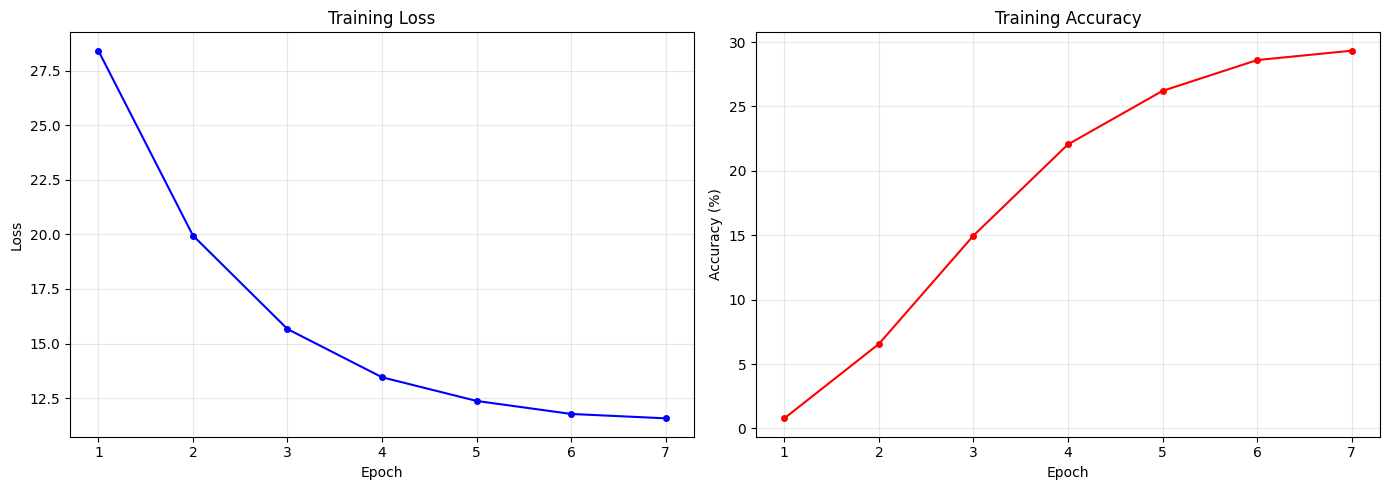

In [8]:
# TRAIN THE MODEL
# Hard guard: do not start another long run unless the active config and loader are really hybrid.
expected_targets = ['q_proj', 'k_proj', 'v_proj', 'out_proj']
print("Active core file:", getattr(sys.modules.get('mobilefacelora_core'), '__file__', 'unknown'))
print("early_stopping_patience:", cfg.get('early_stopping_patience'))
print("epochs:", cfg['epochs'])
print("lora_targets:", cfg['lora_targets'])
print("use_pk_sampler:", cfg.get('use_pk_sampler'))
print("use_teacher_distillation:", cfg.get('use_teacher_distillation'))
print("loader_has_teacher_images:", getattr(train_dataset, 'teacher_transform', None) is not None)

assert cfg['lora_targets'] == expected_targets, "Wrong config: expected q,k,v,out LoRA for hybrid run."
assert cfg.get('use_pk_sampler') is True, "Wrong config: P x K sampler is not enabled."
assert cfg.get('use_teacher_distillation') is True, "Wrong config: teacher distillation is not enabled."
assert getattr(train_dataset, 'teacher_transform', None) is not None, "Wrong loader: build_training_data(cfg) was not used."
assert cfg.get('early_stopping_patience') is None or cfg.get('early_stopping_patience') >= 3, "Patience is too low for this run."

# Optional: benchmark check during training.
def quick_eval(m):
    print("  [Sanity Check]")
    return evaluate_all_benchmarks(m, cfg, device)

print(f"Starting training: {cfg['epochs']} epochs, batch_size={cfg['batch_size']}, lr={cfg['lr']}")
print(f"LoRA rank={cfg['lora_rank']}, alpha={cfg['lora_alpha']}")
print(f"Teacher: {cfg.get('teacher_type')} / {cfg.get('teacher_model_name')} / weight={cfg.get('distill_weight')}")
print()

start_time = time.time()
history = train(model, train_loader, cfg, device, eval_fn=quick_eval)
train_time = time.time() - start_time

print(f"\nTraining complete in {train_time/60:.1f} minutes")

save_path = os.path.join(cfg['output_dir'], 'mobilefacelora_trained.pth')
torch.save(model.state_dict(), save_path)
print(f"Model saved: {save_path}")

plot_training_history(history, cfg['output_dir'])


### ═══ PHASE 7: BENCHMARK EVALUATION ═══

Standard FR evaluation protocol:
1. Extract L2-normalized embeddings for all pair images
2. Compute L2 distance between each pair
3. **10-fold cross-validation** to find optimal threshold
4. Report accuracy and std across folds

Benchmarks: LFW, AgeDB-30, CALFW, CPLFW (6,000 pairs each)

In [ ]:
# ═══ FULL BENCHMARK EVALUATION ═══
print("Evaluating trained MobileFaceLoRA on all benchmarks...")
print()

benchmark_results = evaluate_all_benchmarks(model, cfg, device)

print("\n" + "="*50)
print("  BENCHMARK RESULTS SUMMARY")
print("="*50)
for name, res in benchmark_results.items():
    print(f"  {name:>10}: {100*res['accuracy']:.2f}% ± {100*res['std']:.2f}%  "
          f"(threshold={res['threshold']:.3f})")

### ═══ PHASE 8: LoRA RANK ABLATION STUDY ═══
*Your original research contribution*

**Research Question:** What LoRA rank gives the best accuracy-vs-size trade-off for mobile face recognition?

We train separate models with ranks **r ∈ {4, 8, 16, 32, 64}** and compare:
- Benchmark accuracy (LFW, AgeDB-30, CALFW, CPLFW)
- Number of trainable parameters
- Model size

In [ ]:
# ═══ LoRA RANK ABLATION STUDY ═══
# Reuses the existing trained rank checkpoint from the main training session.
# All other ranks are trained from scratch.

ablation_ranks = [4, 8, 16, 32, 64]
ablation_cfg = cfg.copy()
ablation_cfg['epochs'] = 5  # Epochs for ranks that still need training

# ── Pre-trained checkpoints: ranks 4, 8, 16 ──
pretrained_checkpoints = {
    4:  os.path.join(cfg['output_dir'], 'mobilefacelora_r4.pth'),
    8:  os.path.join(cfg['output_dir'], 'mobilefacelora_trained.pth'),
    16: os.path.join(cfg['output_dir'], 'mobilefacelora_r16.pth'),
}
# Only keep checkpoints that actually exist on disk
pretrained_checkpoints = {
    r: p for r, p in pretrained_checkpoints.items() if os.path.exists(p)
}

ranks_to_train = [r for r in ablation_ranks if r not in pretrained_checkpoints]
ranks_to_load  = [r for r in ablation_ranks if r in pretrained_checkpoints]

print(f'Ablation ranks:          {ablation_ranks}')
print(f'Pre-trained (eval only): {ranks_to_load}')
print(f'Need training:           {ranks_to_train}')
print(f'Epochs per new rank:     {ablation_cfg["epochs"]}')
print()

# ── Prepare training data ──
train_transform = get_train_transforms(
    ablation_cfg['input_size'],
    mean=ablation_cfg.get('preprocess_mean'),
    std=ablation_cfg.get('preprocess_std'),
)
train_ds = VGGFace2Dataset(ablation_cfg['train_dir'], train_transform)
train_loader = DataLoader(
    train_ds, batch_size=ablation_cfg['batch_size'], shuffle=True,
    num_workers=ablation_cfg['num_workers'], pin_memory=True,
    drop_last=True,
    persistent_workers=(ablation_cfg['num_workers'] > 0))

ablation_results = []

for rank in ablation_ranks:
    print(f"\n{'='*60}")
    print(f'  ABLATION: LoRA rank = {rank}')
    print(f"{'='*60}")

    rank_cfg = {**ablation_cfg, 'lora_rank': rank, 'lora_alpha': rank * 2}
    model = build_model(rank_cfg, train_ds.num_classes, device)

    if rank in pretrained_checkpoints:
        # ── Load existing checkpoint (no retraining) ──
        ckpt_path = pretrained_checkpoints[rank]
        print(f'  Loading pre-trained checkpoint: {ckpt_path}')
        state = torch.load(ckpt_path, map_location=device, weights_only=True)
        model.load_state_dict(state)
        del state
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        final_loss = None
        final_acc  = None
        print('  ✓ Checkpoint loaded — skipping training.')
    else:
        # ── Train from scratch ──
        print(f'  Training for {rank_cfg["epochs"]} epochs...')
        history = train(model, train_loader, rank_cfg, device)
        final_loss = history['loss'][-1]
        final_acc  = history['acc'][-1]
        # Save checkpoint
        ckpt_path = os.path.join(
            ablation_cfg['output_dir'], f'mobilefacelora_r{rank}.pth')
        torch.save(model.state_dict(), ckpt_path)
        print(f'  Saved: {ckpt_path}')

    # ── Benchmark evaluation (always) ──
    print('\nBenchmark Evaluation:')
    bench = evaluate_all_benchmarks(model, rank_cfg, device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    result = {
        'rank': rank,
        'trainable_params_M': trainable / 1e6,
        'total_params_M': total_p / 1e6,
        'param_ratio': trainable / total_p,
        'final_loss': final_loss,
        'final_train_acc': final_acc,
    }
    for bname, bres in bench.items():
        result[f'{bname}_acc'] = bres['accuracy']
    ablation_results.append(result)

    # Free GPU memory before next rank
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

# ── Save results ──
results_path = os.path.join(cfg['output_dir'], 'ablation_results.json')
with open(results_path, 'w') as f:
    json.dump(ablation_results, f, indent=2)
print(f'\n✓ All results saved: {results_path}')


In [ ]:
# ═══ ABLATION VISUALIZATIONS (Thesis Figures) ═══
print_results_table(ablation_results)
plot_ablation_results(ablation_results, cfg['output_dir'])

### ═══ PHASE 9: MOBILE EXPORT PIPELINE ═══

Export pipeline for mobile deployment:
1. **Remove** ArcFace head (not needed at inference)
2. **Merge** LoRA weights into base model (no PEFT dependency at runtime)
3. Export to **ONNX** format
4. Optionally convert to **TFLite** with INT8 quantization

In [ ]:
# ═══ MOBILE EXPORT ═══
# Use the best model from ablation, or the single trained model
print("Exporting model for mobile deployment...")
onnx_path, onnx_size = export_for_mobile(model, cfg, device)

print(f"\n--- Export Summary ---")
print(f"  ONNX model: {onnx_path}")
print(f"  ONNX size:  {onnx_size:.1f} MB")
print(f"\nTo convert to TFLite (run in terminal):")
print(f"  pip install onnx2tf tensorflow")
print(f"  onnx2tf -i {onnx_path} -o ./outputs/face_model_tf/")
print(f"  # Then quantize with TFLite converter for INT8")